In [ ]:
%pip install scikit-learn pandas matplotlib optuna h5py

In [ ]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\Lily\AppData\Local\Programs\Python\Python311\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [ ]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import optuna
import sklearn

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("h5py:", h5py.__version__)
print("Optuna:", optuna.__version__)
print("Scikit-learn:", sklearn.__version__)

NumPy: 2.4.6
Pandas: 3.0.5
h5py: 3.16.0
Optuna: 5.0.0
Scikit-learn: 1.9.1


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
# Abre o arquivo HDF5 e lista os datasets armazenados nele

arquivo = "3D MNIST/full_dataset_vectors.h5"

with h5py.File(arquivo, "r") as f:
    print("Conteúdo do arquivo:")
    print(list(f.keys()))

Conteúdo do arquivo:
['X_test', 'X_train', 'y_test', 'y_train']


In [ ]:
# Mostra o formato e o tipo de dado de cada dataset dentro do arquivo HDF5

with h5py.File(arquivo, "r") as f:
    for chave in f.keys():
        dataset = f[chave]

        print(
            f"{chave}: "
            f"shape={dataset.shape}, "
            f"dtype={dataset.dtype}"
        )

X_test: shape=(2000, 4096), dtype=float64
X_train: shape=(10000, 4096), dtype=float64
y_test: shape=(2000,), dtype=int64
y_train: shape=(10000,), dtype=int64


In [ ]:
# Carrega os dados de treinamento e teste armazenados no arquivo HDF5

with h5py.File(arquivo, "r") as f:
    X_train = f["X_train"][:]
    y_train = f["y_train"][:]
    X_test = f["X_test"][:]
    y_test = f["y_test"][:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (10000, 4096)
y_train: (10000,)
X_test: (2000, 4096)
y_test: (2000,)


X_train = atributos usados para treinamento
y_train = respostas corretas do treinamento

X_test = atributos reservados para o teste final
y_test = respostas corretas do teste final

In [ ]:
# Identifica as classes do conjunto de treinamento e conta quantos exemplos existem em cada classe

classes, quantidades = np.unique(
    y_train,
    return_counts=True
)

distribuicao = pd.DataFrame({
    "Classe": classes,
    "Quantidade": quantidades
})

distribuicao

,Classe,Quantidade
0,0,958
1,1,1126
2,2,976
3,3,986
4,4,1070
5,5,868
6,6,1002
7,7,1100
8,8,924
9,9,990


In [ ]:
# Verifica valores ausentes e analisa a escala dos atributos do conjunto de treinamento

print("Valores ausentes:", np.isnan(X_train).sum())
print("Valor mínimo:", X_train.min())
print("Valor máximo:", X_train.max())
print("Média:", X_train.mean())
print("Desvio padrão:", X_train.std())

Valores ausentes: 0
Valor mínimo: 0.0
Valor máximo: 1.0
Média: 0.06742186928169411
Desvio padrão: 0.17518264756674443


Importante analizar:

- Há NaN?
- Os valores vão de 0 a 1?
- Vão de 0 a 255?
- Existem valores negativos?
- Todos os atributos estão aproximadamente na mesma escala?

In [ ]:
# Exibe os primeiros valores de uma amostra e sua classe correta

indice = 0

print("Primeiros 30 atributos:")
print(X_train[indice][:30])

print("\nQuantidade total de atributos:")
print(len(X_train[indice]))

print("\nClasse correta:")
print(y_train[indice])

Primeiros 30 atributos:
[0.         0.         0.         0.         0.         0.8372093
 0.8372093  0.8372093  0.8372093  0.8372093  0.8372093  0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.62790698 0.41860465 0.41860465
 0.41860465 0.41860465 0.62790698 0.         0.         0.        ]

Quantidade total de atributos:
4096

Classe correta:
5


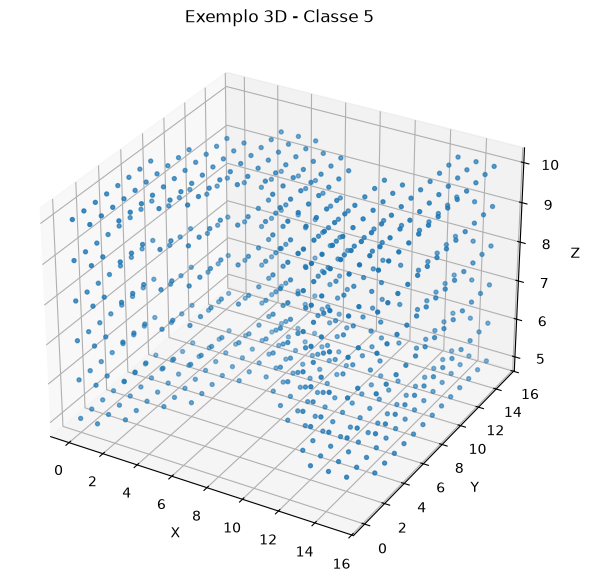

In [ ]:
# Visualiza em 3D os voxels ativos de uma amostra do dataset

indice = 0
amostra_3d = X_train[indice].reshape(16, 16, 16)

x, y, z = np.where(amostra_3d > 0)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x, y, z, s=8)

ax.set_title(f"Exemplo 3D - Classe {y_train[indice]}")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

In [ ]:
# Configura validação cruzada estratificada para preservar a proporção das classes

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print(cv)

StratifiedKFold(n_splits=3, random_state=42, shuffle=True)


In [ ]:
# Define Accuracy e F1 Macro como métricas para avaliar a classificação

metricas = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro"
}

print(metricas)

{'accuracy': 'accuracy', 'f1_macro': 'f1_macro'}


In [ ]:
# Cria uma MLP inicial com padronização dos dados para obter um desempenho de referência

pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "mlp",
        MLPClassifier(
            hidden_layer_sizes=(128,),
            activation="relu",
            solver="adam",
            learning_rate_init=0.001,
            max_iter=300,
            early_stopping=True,
            random_state=42
        )
    )
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('mlp', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128,)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or '

In [ ]:
# Avalia a MLP inicial com validação cruzada usando Accuracy e F1 Macro

resultado_baseline = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=metricas,
    return_train_score=True,
    n_jobs=1
)

print(
    "Accuracy média:",
    resultado_baseline["test_accuracy"].mean()
)

print(
    "F1 Macro médio:",
    resultado_baseline["test_f1_macro"].mean()
)

Accuracy média: 0.6190998823937582
F1 Macro médio: 0.6129931353221751


### Desempenho da configuração inicial

A configuração inicial da MLP foi avaliada utilizando validação cruzada
estratificada com 3 folds.

Foram obtidos:

- Accuracy média: aproximadamente 61,91%
- F1 Macro médio: aproximadamente 61,30%

Esses resultados serão utilizados apenas como referência inicial para observar
o efeito posterior do ajuste de hiperparâmetros. O conjunto de teste reservado
não foi utilizado nesta etapa.

In [ ]:
return_train_score=True